# 01_01 · EDA — AI4I Predictive Maintenance

**Dataset:** AI4I 2020 Predictive Maintenance (UCI, CC BY 4.0)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

sns.set_theme(style='whitegrid')
%matplotlib inline

AI4I_PATH = '../data/raw/ai4i2020.csv'


## 1. AI4I — Carga y visión general

Cargamos el dataset y verificamos su integridad: dimensiones, tipos de dato y valores nulos.

En un entorno industrial, un valor nulo puede indicar un sensor caído o un registro corrupto.
Detectarlo aquí evita que el modelo aprenda de datos erróneos.


In [2]:
ai4i = pd.read_csv(AI4I_PATH)
print('Shape:', ai4i.shape)
ai4i.head()


Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(ai4i.info())
print('\nNulos:', ai4i.isnull().sum().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## 3. Distribuciones de las variables numéricas — AI4I

Analizamos la distribución de cada variable continua para detectar:
- **Asimetrías** que podrían indicar que la variable sigue patrones de fallo
- **Outliers** que podrían distorsionar el modelo o indicar errores de medición
- **Rango real** vs rango documentado (validación de calidad)

Las variables con distribuciones muy sesgadas serán candidatas a feature engineering.


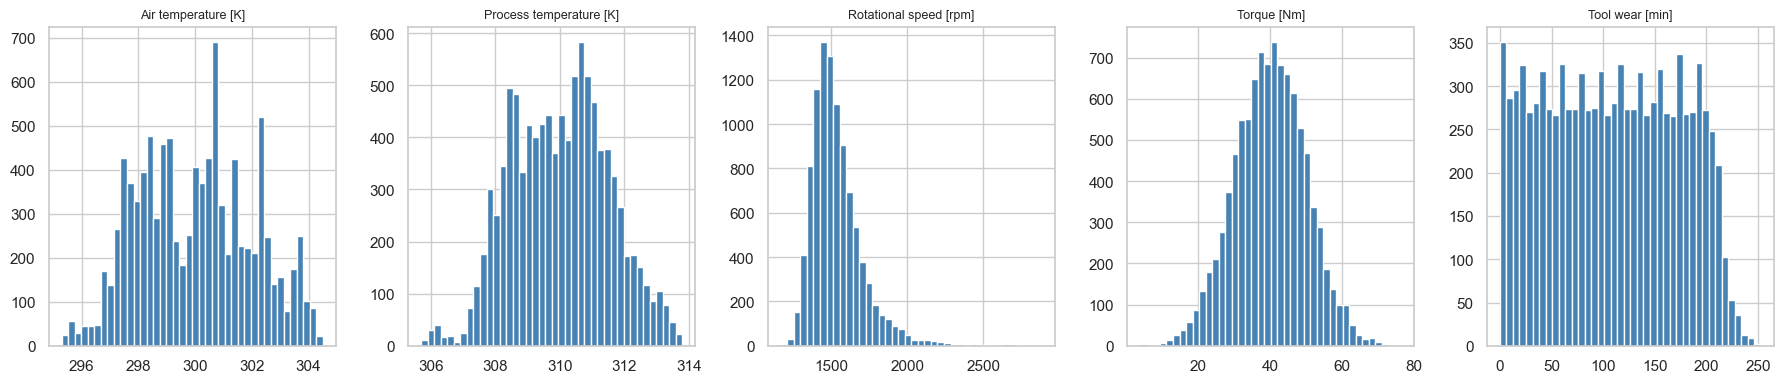

In [4]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    ai4i[col].hist(ax=ax, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Variable objetivo — desbalanceo de clases

El desbalanceo de clases es el problema central de este proyecto.

Con solo el **3.4% de fallos**, un modelo que prediga siempre "Normal" obtendría
un 96.6% de accuracy sin aprender nada útil. Por eso:
- **No usaremos accuracy** como métrica principal
- **Usaremos Recall y F1** orientados a la clase fallo
- Aplicaremos técnicas de manejo del desbalanceo: `class_weight='balanced'` y ajuste de umbral


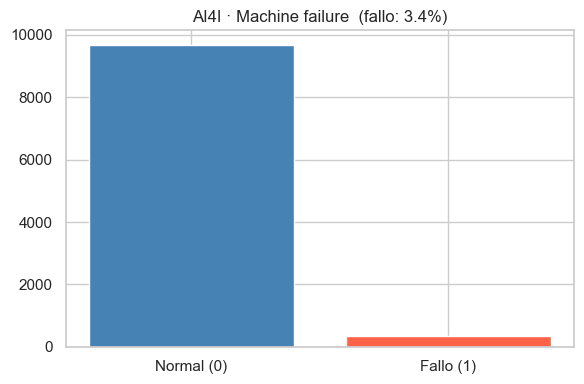

In [5]:
counts = ai4i['Machine failure'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Normal (0)', 'Fallo (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title(f'AI4I · Machine failure  (fallo: {counts[1]/len(ai4i):.1%})')
plt.tight_layout(); plt.show()


## 5. Tipos de fallo AI4I

El dataset registra 5 modos de fallo independientes. Entender cuál es más frecuente
es clave porque:
- Los modos frecuentes (OSF, HDF) tienen más ejemplos → el modelo los detecta mejor
- Los modos raros (RNF) tienen muy pocos ejemplos → son difíciles de aprender
- Algunos modos están determinados por **reglas físicas observables** en los sensores
  (HDF, PWF, OSF) → el feature engineering puede capturarlos directamente
- El RNF ocurre con probabilidad fija del 0.1% **sin firma en sensores** → irreducible


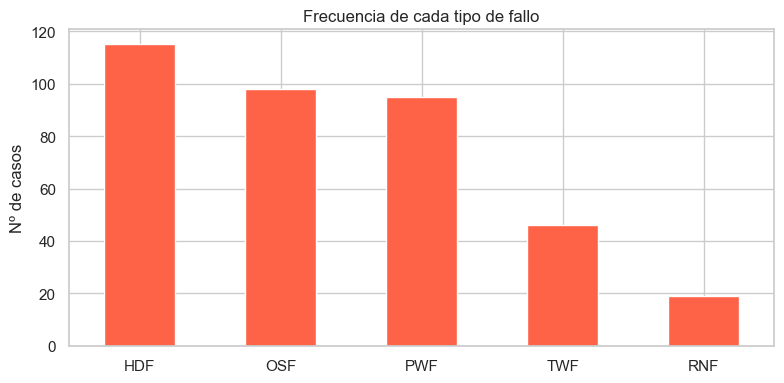

In [6]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
ai4i[failure_types].sum().sort_values(ascending=False).plot(
    kind='bar', color='tomato', edgecolor='white', figsize=(8, 4))
plt.title('Frecuencia de cada tipo de fallo')
plt.ylabel('Nº de casos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Correlaciones entre variables — AI4I

Las correlaciones nos revelan dos cosas:
1. **Correlación con la variable objetivo**: qué features tienen señal predictiva directa
2. **Correlación entre features (multicolinealidad)**: features muy correlacionadas
   aportan información redundante

> **Nota técnica:** los modelos de árboles (RF, LGBM, XGB) son más robustos a la
> multicolinealidad que los modelos lineales, pero sigue siendo importante conocerla
> para el feature engineering y la interpretación.


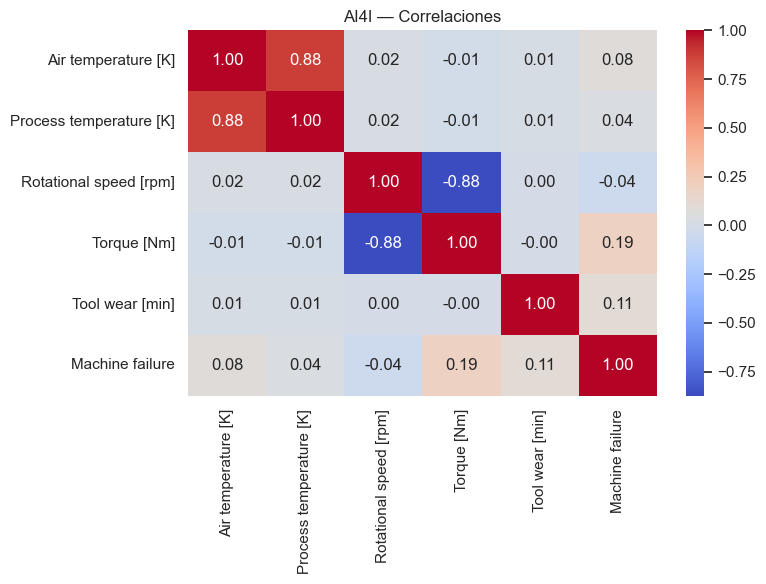

In [7]:
corr = ai4i[num_cols + ['Machine failure']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('AI4I — Correlaciones')
plt.tight_layout()
plt.show()


## 9. Conclusiones EDA — AI4I

- **Sin problemas de calidad**: 0 nulos, 0 duplicados, rangos coherentes
- **Desbalanceo severo**: 3.4% fallos → necesita manejo explícito
- **Correlación negativa** Torque–Velocidad: relación física de potencia constante
- **OSF y HDF** son los fallos más frecuentes → el modelo los detectará mejor
- **RNF** es intrínsecamente no predecible (fallo aleatorio sin firma en sensores)

### Implicaciones para 02_01_Preprocesado_AI4I
- Feature engineering: calcular `Power`, `Temp_diff`, `Wear×Torque`
- Escalado: necesario para SVM y el meta-modelo del stacking
- Manejo del desbalanceo: `class_weight='balanced'` + ajuste de umbral


## 10. Análisis bivariado por modo de fallo

Cada tipo de fallo está determinado por condiciones físicas específicas.
Visualizar la distribución de las features clave para cada modo ayuda a entender
qué señales discriminan cada fallo y **por qué el feature engineering escogido tiene sentido**.


/tmp/claude-501/ipykernel_56209/1425864980.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/claude-501/ipykernel_56209/1425864980.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/claude-501/ipykernel_56209/1425864980.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/claude-501/ipykernel_56209/1425864980.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/claude-501/ipykernel_56209/1425864980.py:20

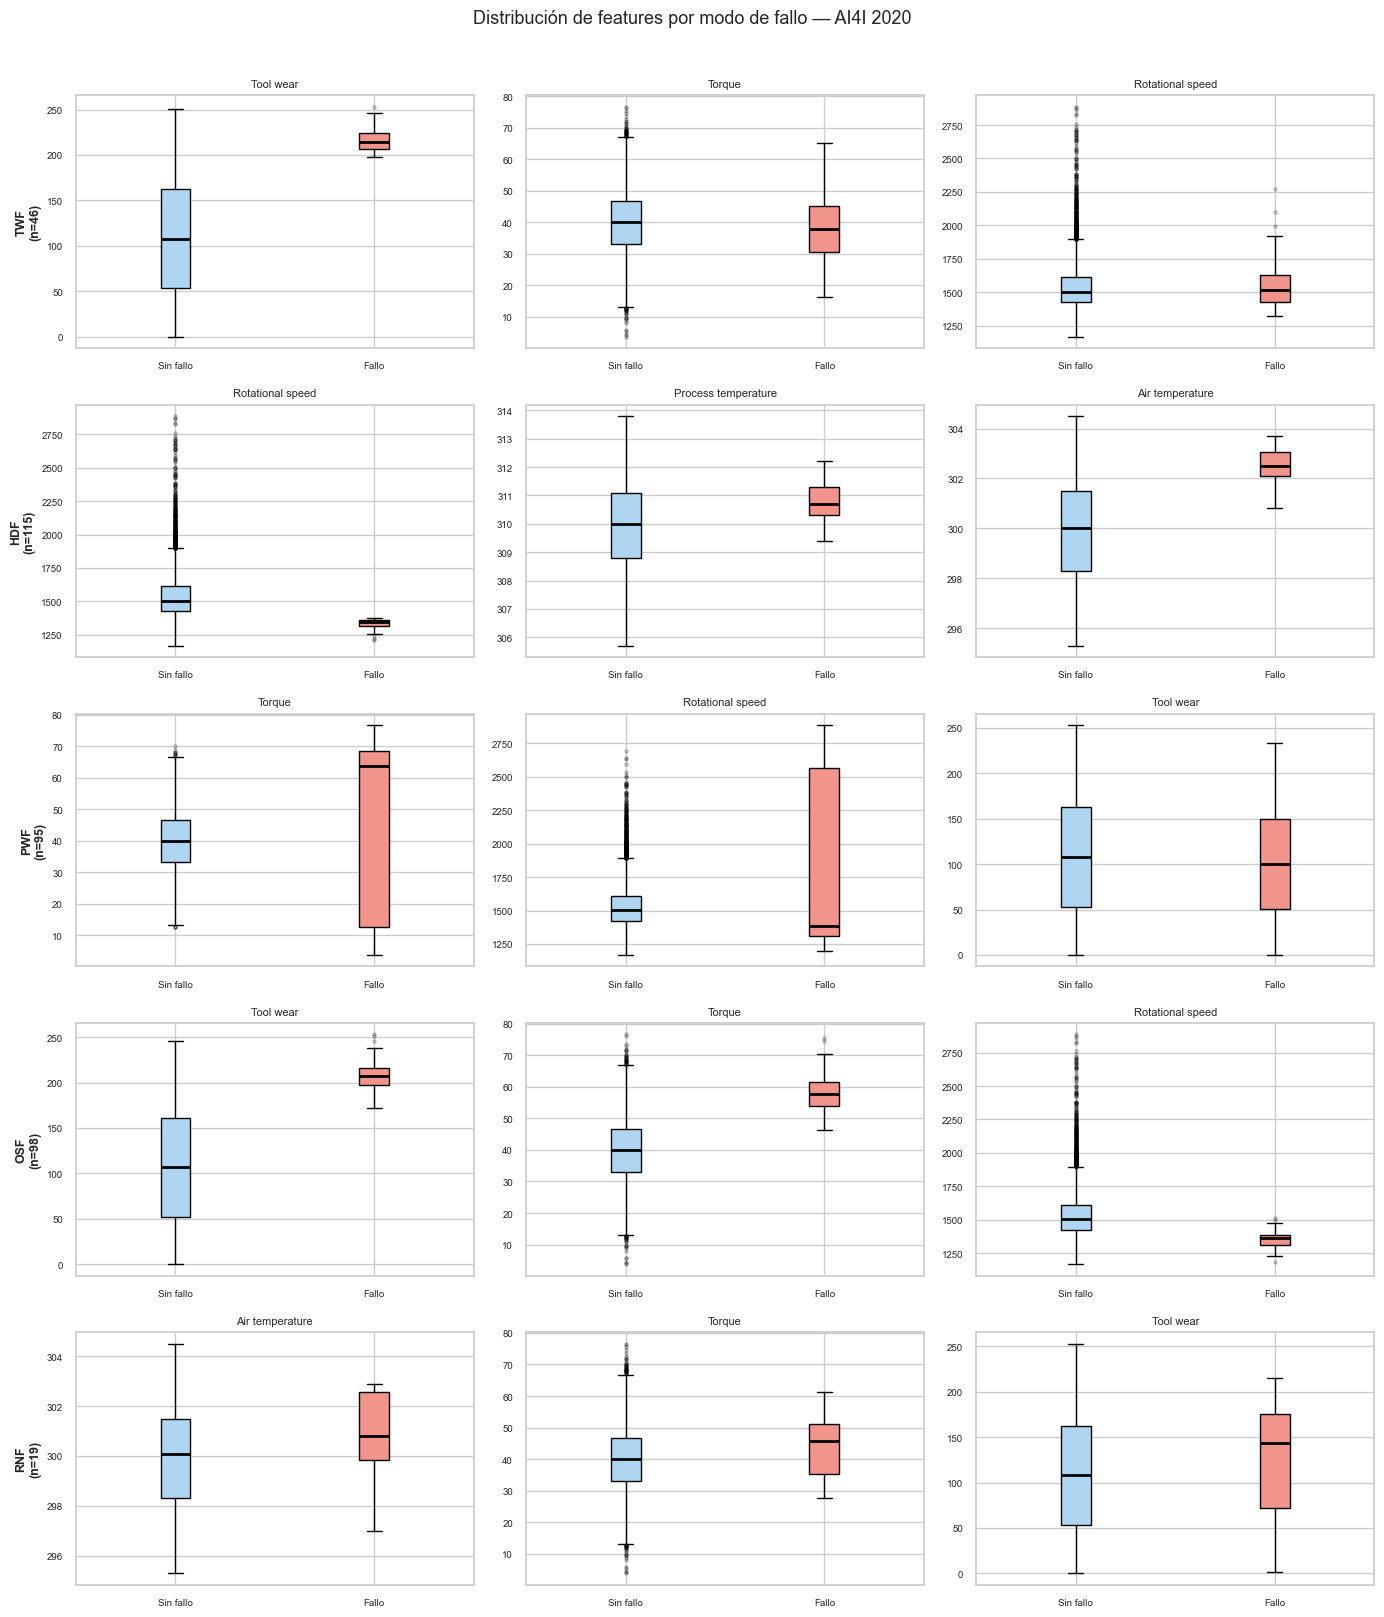

In [8]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Features más relevantes para cada modo según las reglas físicas del dataset
top_feats = {
    'TWF': ['Tool wear [min]',       'Torque [Nm]',               'Rotational speed [rpm]'],
    'HDF': ['Rotational speed [rpm]','Process temperature [K]',   'Air temperature [K]'],
    'PWF': ['Torque [Nm]',           'Rotational speed [rpm]',    'Tool wear [min]'],
    'OSF': ['Tool wear [min]',       'Torque [Nm]',               'Rotational speed [rpm]'],
    'RNF': ['Air temperature [K]',   'Torque [Nm]',               'Tool wear [min]'],
}

fig, axes = plt.subplots(len(failure_types), 3, figsize=(14, 16))

for row_idx, ft in enumerate(failure_types):
    n_pos = ai4i[ft].sum()
    for col_idx, feat in enumerate(top_feats[ft]):
        ax = axes[row_idx, col_idx]
        data_0 = ai4i[ai4i[ft] == 0][feat].values
        data_1 = ai4i[ai4i[ft] == 1][feat].values
        bp = ax.boxplot(
            [data_0, data_1],
            labels=['Sin fallo', 'Fallo'],
            patch_artist=True,
            medianprops=dict(color='black', lw=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
        )
        bp['boxes'][0].set_facecolor('#AED6F1')
        bp['boxes'][1].set_facecolor('#F1948A')
        if col_idx == 0:
            ax.set_ylabel(f'{ft}\n(n={n_pos})', fontsize=9, fontweight='bold')
        ax.set_title(feat.split(' [')[0], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Distribución de features por modo de fallo — AI4I 2020',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Conclusiones del análisis bivariado

| Modo | Feature clave | Patrón observado |
|---|---|---|
| **TWF** | Tool wear | Distribución sesgada a valores altos (> 200 min) |
| **HDF** | Rotational speed | Velocidades bajas (< 1380 rpm) + pequeña Δ temperatura |
| **PWF** | Torque + speed | Valores extremos de par combinados con alta/baja velocidad |
| **OSF** | Wear + Torque | Ambos altos simultáneamente → producto supera umbral |
| **RNF** | Ninguna | Sin separación observable — fallo completamente aleatorio |

**Esto justifica directamente el feature engineering del notebook 02:**
- `Power = Torque × ω` captura la condición de PWF
- `Temp_diff = Process T − Air T` captura la condición de HDF
- `Wear×Torque` captura la condición de OSF
